In [2]:
from google.colab import files
uploaded = files.upload()


Saving ecommerce_customer_data_custom_ratios.csv to ecommerce_customer_data_custom_ratios.csv


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from datetime import timedelta

plt.rcParams['figure.figsize'] = (8,5)
plt.rcParams['font.size'] = 11


df = pd.read_csv("ecommerce_customer_data_custom_ratios.csv")
df.shape, df.columns


((250000, 13),
 Index(['Customer ID', 'Purchase Date', 'Product Category', 'Product Price',
        'Quantity', 'Total Purchase Amount', 'Payment Method', 'Customer Age',
        'Returns', 'Customer Name', 'Age', 'Gender', 'Churn'],
       dtype='object'))

In [16]:
display(df.head())
df.info()
df.isnull().sum().sort_values(ascending=False).head(20)

df.columns = [c.strip() for c in df.columns]

before = df.shape[0]
df = df.drop_duplicates()
print(f"Dropped duplicates: {before - df.shape[0]}")

if 'Product Category' in df.columns:
    df['Product Category'] = df['Product Category'].astype(str).str.strip().str.title()
if 'Payment Method' in df.columns:
    df['Payment Method'] = df['Payment Method'].astype(str).str.strip().str.title()

date_col = 'Purchase Date'
df[date_col] = pd.to_datetime(df[date_col], errors='coerce')

df['Total Purchase Amount'] = pd.to_numeric(df['Total Purchase Amount'], errors='coerce')
df['Product Price'] = pd.to_numeric(df['Product Price'], errors='coerce')
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')

display(df.head())
print("Missing after cleaning:\n", df.isnull().mean().sort_values(ascending=False).head(10))




,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,46251,2020-09-08 09:38:32,Electronics,12,3,740,Credit Card,37,0.0,Christine Hernandez,37,Male,0
1,46251,2022-03-05 12:56:35,Home,468,4,2739,PayPal,37,0.0,Christine Hernandez,37,Male,0
2,46251,2022-05-23 18:18:01,Home,288,2,3196,PayPal,37,0.0,Christine Hernandez,37,Male,0
3,46251,2020-11-12 13:13:29,Clothing,196,1,3509,PayPal,37,0.0,Christine Hernandez,37,Male,0
4,13593,2020-11-27 17:55:11,Home,449,1,3452,Credit Card,49,0.0,James Grant,49,Female,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer ID            250000 non-null  int64  
 1   Purchase Date          250000 non-null  object 
 2   Product Category       250000 non-null  object 
 3   Product Price          250000 non-null  int64  
 4   Quantity               250000 non-null  int64  
 5   Total Purchase Amount  250000 non-null  int64  
 6   Payment Method         250000 non-null  object 
 7   Customer Age           250000 non-null  int64  
 8   Returns                202404 non-null  float64
 9   Customer Name          250000 non-null  object 
 10  Age                    250000 non-null  int64  
 11  Gender                 250000 non-null  object 
 12  Churn                  250000 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 24.8+ MB
Dropped duplicates: 0


,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,46251,2020-09-08 09:38:32,Electronics,12,3,740,Credit Card,37,0.0,Christine Hernandez,37,Male,0
1,46251,2022-03-05 12:56:35,Home,468,4,2739,Paypal,37,0.0,Christine Hernandez,37,Male,0
2,46251,2022-05-23 18:18:01,Home,288,2,3196,Paypal,37,0.0,Christine Hernandez,37,Male,0
3,46251,2020-11-12 13:13:29,Clothing,196,1,3509,Paypal,37,0.0,Christine Hernandez,37,Male,0
4,13593,2020-11-27 17:55:11,Home,449,1,3452,Credit Card,49,0.0,James Grant,49,Female,1


Missing after cleaning:
 Returns                  0.190384
Purchase Date            0.000000
Product Category         0.000000
Product Price            0.000000
Customer ID              0.000000
Quantity                 0.000000
Total Purchase Amount    0.000000
Payment Method           0.000000
Customer Age             0.000000
Customer Name            0.000000
dtype: float64


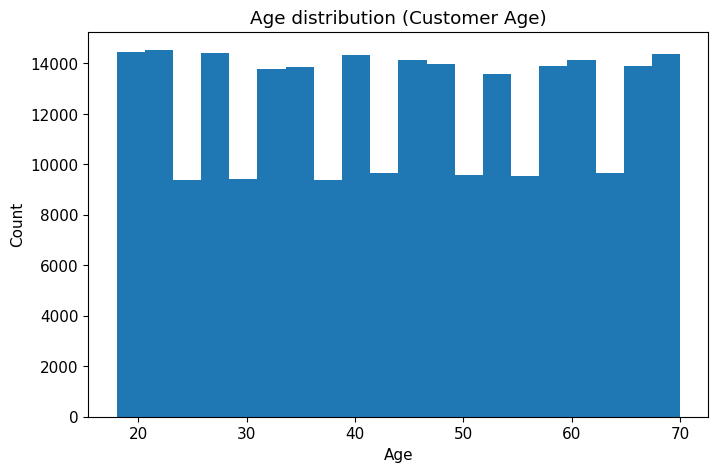

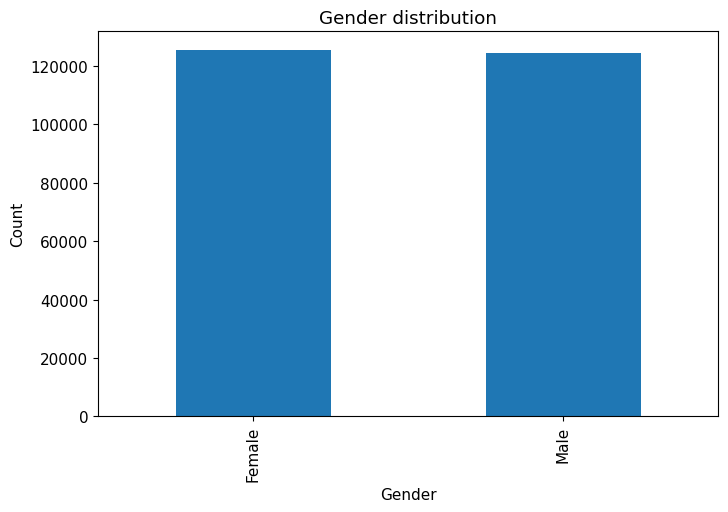

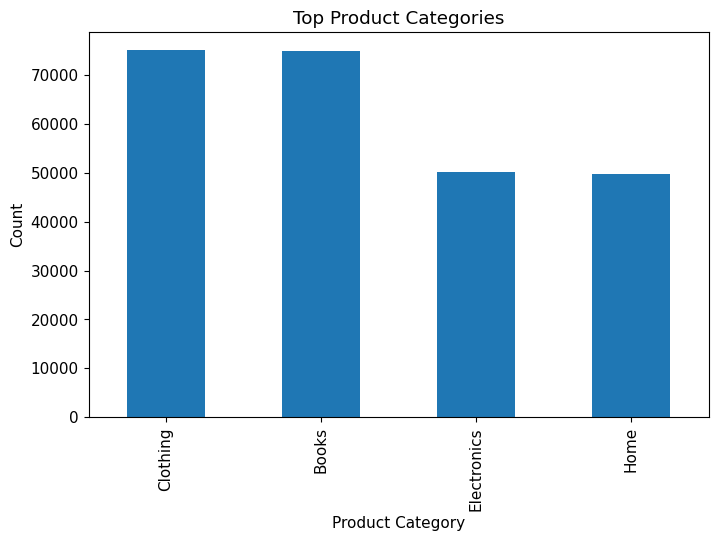

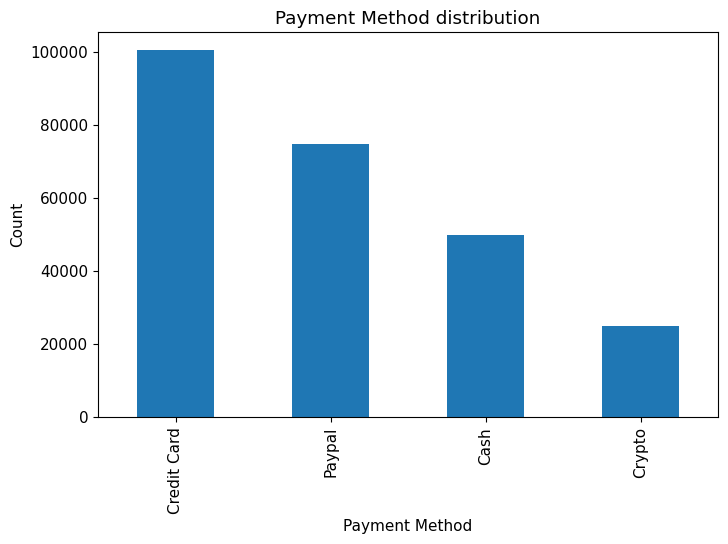

In [17]:
age_col = 'Customer Age' if 'Customer Age' in df.columns and df['Customer Age'].notna().sum()>0 else ('Age' if 'Age' in df.columns else None)
if age_col:
    ages = pd.to_numeric(df[age_col], errors='coerce').dropna()
    plt.hist(ages, bins=20)
    plt.title(f"Age distribution ({age_col})")
    plt.xlabel("Age")
    plt.ylabel("Count")
    plt.show()
else:
    print("No age column available.")

if 'Gender' in df.columns:
    df['Gender'].value_counts().plot(kind='bar')
    plt.title("Gender distribution")
    plt.ylabel("Count")
    plt.show()

if 'Product Category' in df.columns:
    df['Product Category'].value_counts().head(15).plot(kind='bar')
    plt.title("Top Product Categories")
    plt.ylabel("Count")
    plt.show()

if 'Payment Method' in df.columns:
    df['Payment Method'].value_counts().plot(kind='bar')
    plt.title("Payment Method distribution")
    plt.ylabel("Count")
    plt.show()


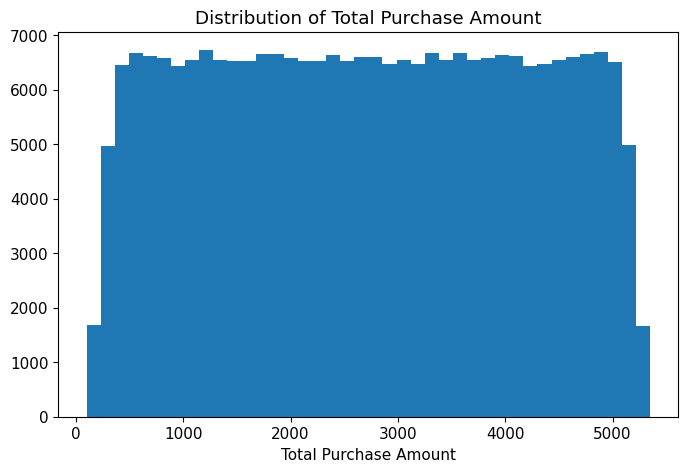

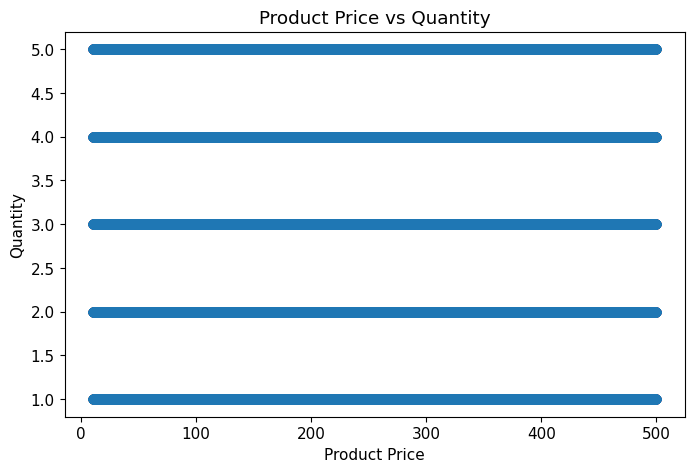

In [18]:
if 'Total Purchase Amount' in df.columns:
    plt.hist(df['Total Purchase Amount'].dropna(), bins=40)
    plt.title("Distribution of Total Purchase Amount")
    plt.xlabel("Total Purchase Amount")
    plt.show()

if 'Product Price' in df.columns and 'Quantity' in df.columns:
    plt.scatter(df['Product Price'].dropna(), df['Quantity'].dropna(), alpha=0.4)
    plt.title("Product Price vs Quantity")
    plt.xlabel("Product Price")
    plt.ylabel("Quantity")
    plt.show()


In [19]:
cust_col = 'Customer ID'
assert cust_col in df.columns, "Customer ID column missing!"

amt_col = 'Total Purchase Amount'
date_col = 'Purchase Date'

df_tx = df.dropna(subset=[cust_col, date_col]).copy()

snapshot_date = df_tx[date_col].max() + timedelta(days=1)
print("Snapshot date (for recency):", snapshot_date.date())

customer_agg = df_tx.groupby(cust_col).agg(
    Frequency = (date_col, "count"),
    LastPurchaseDate = (date_col, "max"),
    FirstPurchaseDate = (date_col, "min"),
    TotalSpent = (amt_col, "sum"),
    AvgOrderValue = (amt_col, "mean")
).reset_index()

customer_agg['Recency'] = (snapshot_date - customer_agg['LastPurchaseDate']).dt.days
customer_agg['TotalSpent'] = customer_agg['TotalSpent'].fillna(0)
customer_agg['AvgOrderValue'] = customer_agg['AvgOrderValue'].fillna(0)

display(customer_agg.head())
customer_agg.describe().transpose()


Snapshot date (for recency): 2023-09-16


,Customer ID,Frequency,LastPurchaseDate,FirstPurchaseDate,TotalSpent,AvgOrderValue,Recency
0,1,1,2023-07-19 19:09:20,2023-07-19 19:09:20,3491,3491.000000,58
1,2,3,2022-11-21 06:48:05,2021-03-05 14:30:42,7988,2662.666667,299
2,3,8,2023-06-18 12:31:42,2020-09-27 22:26:24,22587,2823.375000,89
3,4,4,2023-05-12 10:50:24,2020-10-09 03:25:04,8715,2178.750000,127
4,5,8,2023-03-28 13:30:55,2020-01-28 14:28:33,12524,1565.500000,171


,count,mean,min,25%,50%,75%,max,std
Customer ID,49673.0,24991.166489,1.0,12491.0,24984.0,37489.0,50000.0,14432.76511
Frequency,49673.0,5.032915,1.0,3.0,5.0,6.0,17.0,2.206427
LastPurchaseDate,49673,2022-12-28 14:11:45.449117440,2020-01-01 14:40:07,2022-09-12 09:47:30,2023-03-14 17:26:21,2023-06-30 03:52:01,2023-09-15 12:24:08,NaN
FirstPurchaseDate,49673,2020-09-18 05:36:33.358423808,2020-01-01 00:15:00,2020-03-18 05:39:54,2020-07-04 23:20:09,2021-01-03 11:26:30,2023-09-15 08:02:40,NaN
TotalSpent,49673.0,13716.559962,110.0,8719.0,13026.0,17966.0,55339.0,6840.208557
AvgOrderValue,49673.0,2724.642085,110.0,2255.714286,2728.6,3191.2,5288.0,737.013884
Recency,49673.0,261.424979,1.0,78.0,185.0,369.0,1353.0,246.024001


In [20]:
rfm = customer_agg[['Customer ID','Recency','Frequency','TotalSpent']].copy().rename(columns={'Customer ID':'CustomerID','TotalSpent':'Monetary'})

rfm['R_score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1,2,3,4])
rfm['M_score'] = pd.qcut(rfm['Monetary'].rank(method='first'), 4, labels=[1,2,3,4])
rfm['RFM_score'] = rfm['R_score'].astype(int)*100 + rfm['F_score'].astype(int)*10 + rfm['M_score'].astype(int)

display(rfm.head())
rfm.describe().transpose()


,CustomerID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score
0,1,58,1,3491,4,1,1,411
1,2,299,3,7988,2,1,1,211
2,3,89,8,22587,3,4,4,344
3,4,127,4,8715,3,2,1,321
4,5,171,8,12524,3,4,2,342


,count,mean,std,min,25%,50%,75%,max
CustomerID,49673.0,24991.166489,14432.765110,1.0,12491.0,24984.0,37489.0,50000.0
Recency,49673.0,261.424979,246.024001,1.0,78.0,185.0,369.0,1353.0
Frequency,49673.0,5.032915,2.206427,1.0,3.0,5.0,6.0,17.0
Monetary,49673.0,13716.559962,6840.208557,110.0,8719.0,13026.0,17966.0,55339.0
RFM_score,49673.0,277.836873,116.520918,111.0,211.0,311.0,411.0,444.0


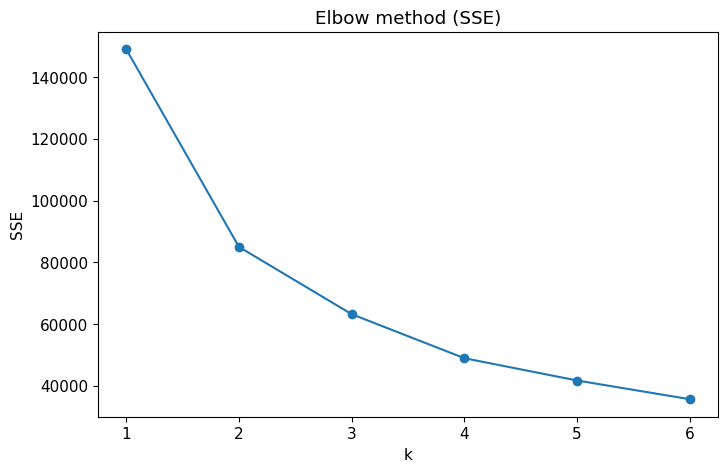

Cluster sizes:
 Cluster
0    18156
1    15716
2     6865
3     8936
Name: count, dtype: int64


,Recency,Frequency,Monetary
Cluster,,,
0,266.063519,3.956685,10357.022910
1,164.356242,6.965660,19482.805641
2,368.774345,1.874165,3865.029836
3,21.869388,5.571008,14669.849230


In [21]:
X = rfm[['Recency','Frequency','Monetary']].copy()

X['Monetary'] = X['Monetary'].replace(0, 1)
X['Frequency'] = X['Frequency'].replace(0, 1)

X_log = np.log1p(X)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

sse = []
for k in range(1,7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    sse.append(km.inertia_)
plt.plot(range(1,7), sse, marker='o')
plt.xlabel("k")
plt.ylabel("SSE")
plt.title("Elbow method (SSE)")
plt.show()

k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)
rfm['Cluster'] = labels

print("Cluster sizes:\n", rfm['Cluster'].value_counts().sort_index())

centroids = scaler.inverse_transform(kmeans.cluster_centers_)
centroids_df = pd.DataFrame(np.expm1(centroids), columns=['Recency','Frequency','Monetary'])
centroids_df.index.name = 'Cluster'
display(centroids_df)


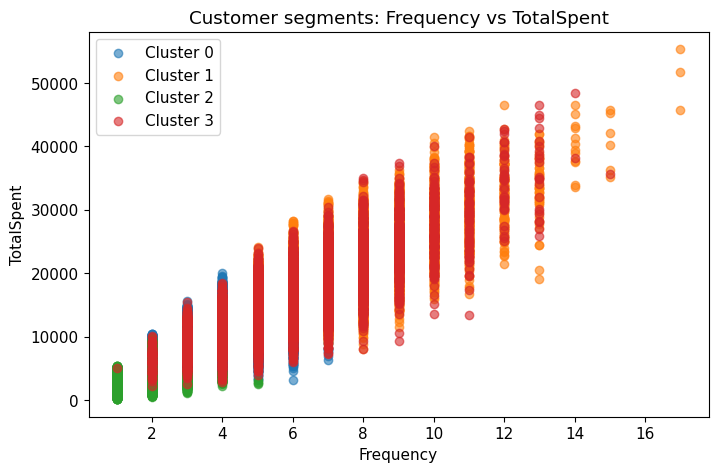

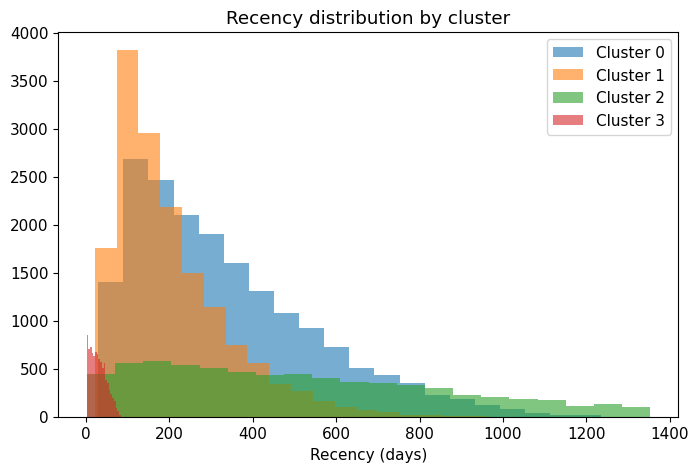

In [22]:
plot_df = customer_agg.merge(rfm[['CustomerID','Cluster']], left_on='Customer ID', right_on='CustomerID', how='left')

for c in sorted(plot_df['Cluster'].dropna().unique()):
    sub = plot_df[plot_df['Cluster']==c]
    plt.scatter(sub['Frequency'], sub['TotalSpent'], alpha=0.6, label=f"Cluster {int(c)}")
plt.xlabel("Frequency")
plt.ylabel("TotalSpent")
plt.title("Customer segments: Frequency vs TotalSpent")
plt.legend()
plt.show()

for c in sorted(plot_df['Cluster'].dropna().unique()):
    plt.hist(plot_df[plot_df['Cluster']==c]['Recency'], bins=20, alpha=0.6, label=f"Cluster {int(c)}")
plt.xlabel("Recency (days)")
plt.title("Recency distribution by cluster")
plt.legend()
plt.show()


In [23]:
rfm_out = rfm.merge(customer_agg[['Customer ID','AvgOrderValue','LastPurchaseDate']], left_on='CustomerID', right_on='Customer ID', how='left')
out_csv = "rfm_segments_customer_analysis.csv"
rfm_out.to_csv(out_csv, index=False)
print("Saved:", out_csv)
display(rfm_out.head())


Saved: rfm_segments_customer_analysis.csv


,CustomerID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score,Cluster,Customer ID,AvgOrderValue,LastPurchaseDate
0,1,58,1,3491,4,1,1,411,2,1,3491.000000,2023-07-19 19:09:20
1,2,299,3,7988,2,1,1,211,0,2,2662.666667,2022-11-21 06:48:05
2,3,89,8,22587,3,4,4,344,1,3,2823.375000,2023-06-18 12:31:42
3,4,127,4,8715,3,2,1,321,0,4,2178.750000,2023-05-12 10:50:24
4,5,171,8,12524,3,4,2,342,1,5,1565.500000,2023-03-28 13:30:55


In [24]:
print("Basic dataset summary:")
print("- Total transactions:", df.shape[0])
print("- Unique customers:", df['Customer ID'].nunique())
print("- Period:", df['Purchase Date'].min(), "to", df['Purchase Date'].max())
print("- Average transaction amount:", round(df['Total Purchase Amount'].mean(),2))

cluster_summary = rfm_out.groupby('Cluster').agg({
    'CustomerID':'count',
    'Recency':'mean',
    'Frequency':'mean',
    'Monetary':'mean'
}).rename(columns={'CustomerID':'NumCustomers'}).reset_index()
display(cluster_summary)

print("\nSuggested insights to include in your report (edit as needed):")
print("- Identify the top 2 clusters that are high monetary & frequency -> target for VIP program.")
print("- Clusters with high recency (large Recency value) are 'At Risk' and need re-engagement campaigns.")
print("- Popular product categories: list top 5 from Product Category counts and propose cross-sell opportunities.")
print("- Use Payment Method distribution to decide promotions (e.g., offer COD discount or card cashback).")


Basic dataset summary:
- Total transactions: 250000
- Unique customers: 49673
- Period: 2020-01-01 00:15:00 to 2023-09-15 12:24:08
- Average transaction amount: 2725.37


,Cluster,NumCustomers,Recency,Frequency,Monetary
0,0,18156,333.063946,4.026107,10719.904880
1,1,15716,202.262090,7.096080,20067.217740
2,2,6865,509.846759,1.950182,4428.368827
3,3,8936,29.073970,5.818263,15771.591764



Suggested insights to include in your report (edit as needed):
- Identify the top 2 clusters that are high monetary & frequency -> target for VIP program.
- Clusters with high recency (large Recency value) are 'At Risk' and need re-engagement campaigns.
- Popular product categories: list top 5 from Product Category counts and propose cross-sell opportunities.
- Use Payment Method distribution to decide promotions (e.g., offer COD discount or card cashback).


In [25]:
display(cluster_summary)

,Cluster,NumCustomers,Recency,Frequency,Monetary
0,0,18156,333.063946,4.026107,10719.904880
1,1,15716,202.262090,7.096080,20067.217740
2,2,6865,509.846759,1.950182,4428.368827
3,3,8936,29.073970,5.818263,15771.591764
